# Sentiment Analysis with ANEW — *Spider-Man: Brand New Day*

1000 reviews do IMDb. Pipeline:

1. lista de valencias ANEW por texto; **classifica quem tem >= 3 palavras no lexico** (score > 50 = positivo);
2. resposta agregada do enunciado (os posts sao, em media, bons ou ruins?);
3. dos textos classificados nasce **o nosso proprio ANEW**, adaptado ao contexto do filme;
4. os textos nao classificados sao reavaliados com ele;
5. correlacao do score com a nota real do autor: so ANEW e pipeline completo.

## 1. Setup e dados

In [1]:
import json
import os
import string
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paleta: azul-marinho + dourado, validados para acessibilidade (CVD e contraste)
AZUL, DOURADO = "#1F4E9C", "#A8762A"
TINTA, LINHA, FUNDO = "#0A1729", "#97A3B4", "#FCFCFB"

anew = pd.read_csv("../anew/anew.csv")
reviews = pd.read_csv("../results/imdb_tt22084616_reviews.csv")
with open("../results/imdb_tt22084616_reviews.json", encoding="utf-8") as fh:
    meta = json.load(fh)["meta"]

VALENCIA = dict(zip(anew["term"], anew["pleasure"]))  # valencia 0-100 por palavra
NEUTRO = 50.0                 # neutro de projeto da escala SAM (5 em 1-9) -> threshold pos/neg
MU = anew["pleasure"].mean()  # media do lexico (58.4) -> espelhamento da negacao

print(f"entidade : {meta['title']} ({meta['year']}) — nota IMDb {meta['imdb_rating']}")
print(f"posts    : {len(reviews)} reviews (de {meta['reviews_available']} disponiveis)")
print(f"lexico   : ANEW com {len(anew)} termos, valencia media {MU:.1f}")

entidade : Spider-Man: Brand New Day (2026) — nota IMDb 8.1
posts    : 1000 reviews (de 2509 disponiveis)
lexico   : ANEW com 1034 termos, valencia media 58.4


## 2. Lista de valencias e classificacao

Para cada texto: tokeniza, casa cada palavra com o ANEW e guarda a **lista de valencias**.
Regras: palavras de topico fora (`movie`, `spider`, `man`, `home` nomeiam o filme, nao
opinam); negacao adjacente espelha a valencia em torno da media do lexico (`not good`:
84.7 -> 32.1). Score do texto = **media das valencias**; textos com menos de 3 palavras no
ANEW ficam sem classificacao nesta etapa. **Score > 50 = positivo, senao negativo.**

In [2]:
PONTUACAO = str.maketrans("", "", string.punctuation)

NEGADORES = {
    "not", "no", "never", "nothing", "none", "neither", "nor", "cannot", "cant",
    "dont", "doesnt", "didnt", "wasnt", "werent", "isnt", "arent", "wont",
    "wouldnt", "couldnt", "shouldnt", "without", "hardly", "barely", "rarely",
}
TOPICO = {"movie", "spider", "man", "home"}  # nomeiam o objeto resenhado, nao opiniao
MIN_PALAVRAS = 3


def tokenizar(texto):
    return texto.translate(PONTUACAO).lower().split()


def valencias(texto, lexico_extra=None):
    """Lista de valencias das palavras do texto (ANEW e, se dado, um lexico extra)."""
    palavras = tokenizar(texto)
    saida = []
    for i, w in enumerate(palavras):
        if w in TOPICO:
            continue
        v = VALENCIA.get(w)
        if v is None and lexico_extra is not None:
            v = lexico_extra.get(w)
        if v is None:
            continue
        if i > 0 and palavras[i - 1] in NEGADORES:
            v = float(np.clip(2 * MU - v, 0, 100))
        saida.append(v)
    return saida


def pontuar(texto, lexico_extra=None):
    """Score = media das valencias; NaN com menos de MIN_PALAVRAS casamentos."""
    vs = valencias(texto, lexico_extra)
    return float(np.mean(vs)) if len(vs) >= MIN_PALAVRAS else np.nan


reviews["valencias"] = reviews["review"].map(valencias)
reviews["score"] = reviews["review"].map(pontuar)
reviews["classe"] = np.where(reviews["score"].isna(), "nao classificado",
                             np.where(reviews["score"] > NEUTRO, "positivo", "negativo"))

print(reviews["classe"].value_counts().to_string())
ex = reviews.iloc[0]
print(f"\nexemplo — {ex['review'][:70]!r}...")
print(f"  valencias: {[round(v, 1) for v in ex['valencias'][:10]]}...")
print(f"  score {ex['score']:.1f} -> {ex['classe']}")

classe
positivo            765
nao classificado    220
negativo             15

exemplo — 'I walked into Spider-Man: Brand New Day expecting another fun MCU movi'...
  valencias: [94.9, 27.3, 84.7, 19.2, 18.3]...
  score 48.9 -> negativo


## 3. A resposta agregada

O enunciado pergunta se os posts sao, em media, bons ou ruins. Media com IC de bootstrap.

In [3]:
s = reviews["score"].dropna()
rng = np.random.default_rng(42)
amostras = np.array([rng.choice(s.values, len(s), replace=True).mean() for _ in range(2000)])
ic = np.percentile(amostras, [2.5, 97.5])

print(f"  score medio do corpus      : {s.mean():.2f} / 100")
print(f"  IC 95% (bootstrap, n=2000) : [{ic[0]:.2f}, {ic[1]:.2f}]")
print(f"  reviews acima do neutro 50 : {100 * (s > NEUTRO).mean():.1f}%")
print("\n  => VEREDITO: sentimento agregado POSITIVO — o IC fica inteiro acima do neutro.")

  score medio do corpus      : 70.46 / 100
  IC 95% (bootstrap, n=2000) : [69.79, 71.13]
  reviews acima do neutro 50 : 98.1%

  => VEREDITO: sentimento agregado POSITIVO — o IC fica inteiro acima do neutro.


## 4. O nosso proprio ANEW

Com os textos que o ANEW classificou (positivos e negativos juntos), aprendemos a valencia
das palavras que o ANEW nao tem: a valencia de uma palavra e a **media do score dos textos
classificados em que ela aparece**. Filtros: presenca em >= 5 textos (estabilidade), desvio
>= 3 pontos da media do corpus (palavra que nao desvia nao discrimina — barra as stopwords),
so palavras alfabeticas de 3+ letras, fora topico e negadores.

Sem vazamento: o dicionario usa apenas scores ANEW, nunca a nota do autor — e os textos
reavaliados nao participaram da construcao (ficaram de fora por nao ter score).

In [4]:
MIN_DOCS = 5     # palavra precisa aparecer em >= 5 textos classificados
MIN_SINAL = 3.0  # e desviar >= 3 pontos da media do corpus para entrar

classificados = reviews.dropna(subset=["score"])
media_corpus = classificados["score"].mean()

docs = defaultdict(list)  # score dos textos em que cada palavra aparece
for texto, sc in zip(classificados["review"], classificados["score"]):
    for w in set(tokenizar(texto)):
        docs[w].append(sc)

PROPRIO = {
    w: float(np.mean(scores))
    for w, scores in docs.items()
    if len(scores) >= MIN_DOCS
    and w not in VALENCIA and w not in TOPICO and w not in NEGADORES
    and w.isalpha() and len(w) >= 3
    and abs(np.mean(scores) - media_corpus) >= MIN_SINAL
}
print(f"  nosso proprio ANEW: {len(PROPRIO)} palavras (ANEW original: {len(anew)})")

print("\n  validade de face — palavras de opiniao que o ANEW nao tem:")
for w in ["boring", "worst", "bad", "awful", "great", "amazing", "masterpiece", "perfect"]:
    m, n = np.mean(docs[w]), len(docs[w])
    destino = "ENTRA" if w in PROPRIO else "fora (desvio < 3)"
    print(f"    {w:<13} media {m:5.1f}  em {n:>3} textos  -> {destino}")

print("\n  O dicionario aprende o lado NEGATIVO ('boring', 'worst', 'bad', 'awful' entram")
print("  abaixo da media). 'great' e 'masterpiece' ficam fora: num corpus quase todo de")
print("  elogio, elas nao desviam da media — o desvio para baixo e que carrega sinal.")

  nosso proprio ANEW: 780 palavras (ANEW original: 1034)

  validade de face — palavras de opiniao que o ANEW nao tem:
    boring        media  65.8  em  34 textos  -> ENTRA
    worst         media  65.1  em  17 textos  -> ENTRA
    bad           media  67.0  em  89 textos  -> ENTRA
    awful         media  65.3  em   8 textos  -> ENTRA
    great         media  70.7  em 271 textos  -> fora (desvio < 3)
    amazing       media  71.6  em 132 textos  -> fora (desvio < 3)
    masterpiece   media  69.8  em  31 textos  -> fora (desvio < 3)
    perfect       media  69.8  em  89 textos  -> fora (desvio < 3)

  O dicionario aprende o lado NEGATIVO ('boring', 'worst', 'bad', 'awful' entram
  abaixo da media). 'great' e 'masterpiece' ficam fora: num corpus quase todo de
  elogio, elas nao desviam da media — o desvio para baixo e que carrega sinal.


In [5]:
nao_class = reviews[reviews["score"].isna()]
reviews["score_proprio"] = nao_class["review"].map(lambda t: pontuar(t, PROPRIO))
# score_final: ANEW quando ha; senao, o nosso dicionario
reviews["score_final"] = reviews["score"].fillna(reviews["score_proprio"])

resgatados = reviews.loc[nao_class.index].dropna(subset=["score_proprio"])
print(f"  nao classificados pelo ANEW    : {len(nao_class)}")
print(f"  reavaliados com o nosso ANEW   : {len(resgatados)} "
      f"({100 * len(resgatados) / len(nao_class):.0f}%)")
print(f"  seguem sem score               : {len(nao_class) - len(resgatados)}")
print(f"  cobertura final                : {reviews['score_final'].notna().sum()} "
      f"de {len(reviews)} ({100 * reviews['score_final'].notna().mean():.1f}%)")

  nao classificados pelo ANEW    : 220
  reavaliados com o nosso ANEW   : 204 (93%)
  seguem sem score               : 16
  cobertura final                : 984 de 1000 (98.4%)


## 5. Resultado: correlacao entre o score e a nota real

Em vez de rotular os reviews pela nota, medimos diretamente se o score (media das
valencias) **anda junto** com a nota que o proprio autor deu (1-10). Usamos a
correlacao de **Spearman** (de ordem): reviews com score maior tendem a ter nota
maior? E a escolha certa aqui porque a nota e ordinal e as escalas sao diferentes —
so importa a direcao, nao a forma da relacao.

Duas populacoes: (1) so os textos pontuados pelo ANEW; (2) todos os textos, incluindo
os reavaliados com o nosso dicionario.

In [6]:
def correlacao(col):
    """Spearman entre o score da coluna e a nota do autor."""
    d = reviews.dropna(subset=[col, "rating"])
    return d, d[col].corr(d["rating"], method="spearman")


# 1) so os textos classificados com o ANEW
val, rho_anew = correlacao("score")
rho = rho_anew  # usado nas figuras

# 2) todos os textos (ANEW + nosso dicionario)
val2, rho_todos = correlacao("score_final")

# so os reavaliados com o nosso dicionario (out-of-sample de verdade)
resg_val = resgatados.dropna(subset=["rating"])
rho_resg = resg_val["score_proprio"].corr(resg_val["rating"], method="spearman")

print("=" * 64)
print(f"  1) so ANEW              (n={len(val):>3}):  correlacao {rho_anew:+.3f}")
print(f"  2) todos (ANEW + nosso) (n={len(val2):>3}):  correlacao {rho_todos:+.3f}")
print("=" * 64)
print(f"  so os reavaliados pelo nosso dicionario (n={len(resg_val)}): {rho_resg:+.3f}")

print("\n=== score_final medio por nota do autor ===")
for nota in range(1, 11):
    m = val2[val2["rating"] == nota]
    if len(m):
        barra = "#" * int(round((m["score_final"].mean() - 60) * 2))
        print(f"  nota {nota:>2}  n={len(m):>3}  score={m['score_final'].mean():.2f}  {barra}")

print("\n  Leitura: a correlacao e positiva — reviews com nota maior tendem a ter score")
print("  maior, e a media por nota sobe de ~64 (nota 1) a ~73 (nota 10) de forma quase")
print("  monotonica. Mas e moderada (~+0.28): prosa comprime o sentimento numa faixa")
print("  estreita de score, entao ha muita sobreposicao entre notas vizinhas. Nos textos")
print("  reavaliados pelo nosso dicionario o sinal e mais fraco (~+0.13) — sao textos")
print("  curtos, com pouca palavra de opiniao. Incluir esses 204 textos amplia a")
print("  cobertura de 765 para 968 sem destruir a correlacao geral.")

  1) so ANEW              (n=765):  correlacao +0.277
  2) todos (ANEW + nosso) (n=968):  correlacao +0.243
  so os reavaliados pelo nosso dicionario (n=203): +0.132

=== score_final medio por nota do autor ===
  nota  1  n= 36  score=64.67  #########
  nota  2  n=  7  score=65.12  ##########
  nota  3  n= 14  score=64.09  ########
  nota  4  n= 12  score=61.27  ###
  nota  5  n= 28  score=65.48  ###########
  nota  6  n=126  score=67.41  ###############
  nota  7  n=168  score=68.82  ##################
  nota  8  n=132  score=71.19  ######################
  nota  9  n=166  score=71.11  ######################
  nota 10  n=279  score=71.98  ########################

  Leitura: a correlacao e positiva — reviews com nota maior tendem a ter score
  maior, e a media por nota sobe de ~64 (nota 1) a ~73 (nota 10) de forma quase
  monotonica. Mas e moderada (~+0.28): prosa comprime o sentimento numa faixa
  estreita de score, entao ha muita sobreposicao entre notas vizinhas. Nos textos
  reava

## 6. Figuras

Tres figuras, salvas em `figuras/`.

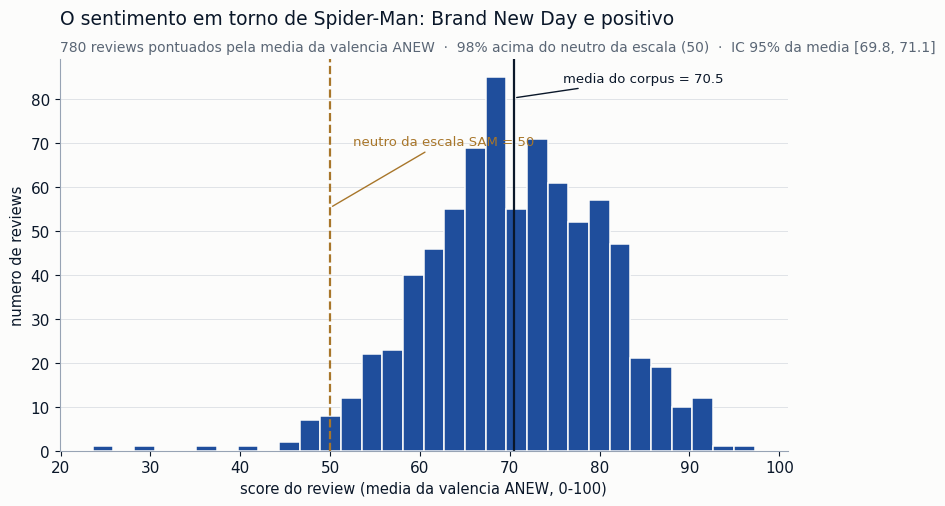

In [7]:
os.makedirs("../figuras", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO,
    "text.color": TINTA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.edgecolor": LINHA, "font.size": 11,
})


def limpar(ax, titulo, sub=None, xlabel=None, ylabel=None):
    """Grid recessivo, sem moldura, titulo a esquerda; pad cresce com o subtitulo."""
    linhas = sub.count("\n") + 1 if sub else 0
    ax.set_title(titulo, fontsize=13.5, loc="left", pad=10 + 15 * linhas)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=10, color="#5A6675",
                va="bottom", linespacing=1.45)
    ax.set_xlabel(xlabel or "", fontsize=10.5)
    ax.set_ylabel(ylabel or "", fontsize=10.5)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.grid(axis="y", color=LINHA, alpha=0.28, lw=0.7)
    ax.set_axisbelow(True)


# ---------- Figura 1: distribuicao dos scores ----------
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(s, bins=32, color=AZUL, edgecolor=FUNDO, linewidth=1.1)
ax.axvline(NEUTRO, color=DOURADO, lw=1.6, ls="--")
ax.axvline(s.mean(), color=TINTA, lw=1.6)
ax.set_xlim(left=min(ax.get_xlim()[0], NEUTRO - 5))

topo = ax.get_ylim()[1]
ax.annotate(f"neutro da escala SAM = {NEUTRO:.0f}", xy=(NEUTRO, topo * 0.62),
            xytext=(NEUTRO + 2.5, topo * 0.78), fontsize=9.5, color=DOURADO,
            ha="left", arrowprops=dict(arrowstyle="-", color=DOURADO, lw=1))
ax.annotate(f"media do corpus = {s.mean():.1f}", xy=(s.mean(), topo * 0.9),
            xytext=(s.mean() + 5.5, topo * 0.94), fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle="-", color=TINTA, lw=1))

limpar(ax, "O sentimento em torno de Spider-Man: Brand New Day e positivo",
       sub=f"{len(s)} reviews pontuados pela media da valencia ANEW  ·  "
           f"{100 * (s > NEUTRO).mean():.0f}% acima do neutro da escala (50)  ·  "
           f"IC 95% da media [{ic[0]:.1f}, {ic[1]:.1f}]",
       xlabel="score do review (media da valencia ANEW, 0-100)", ylabel="numero de reviews")
fig.tight_layout()
fig.savefig("../figuras/fig1_distribuicao.png", dpi=200)
plt.show()

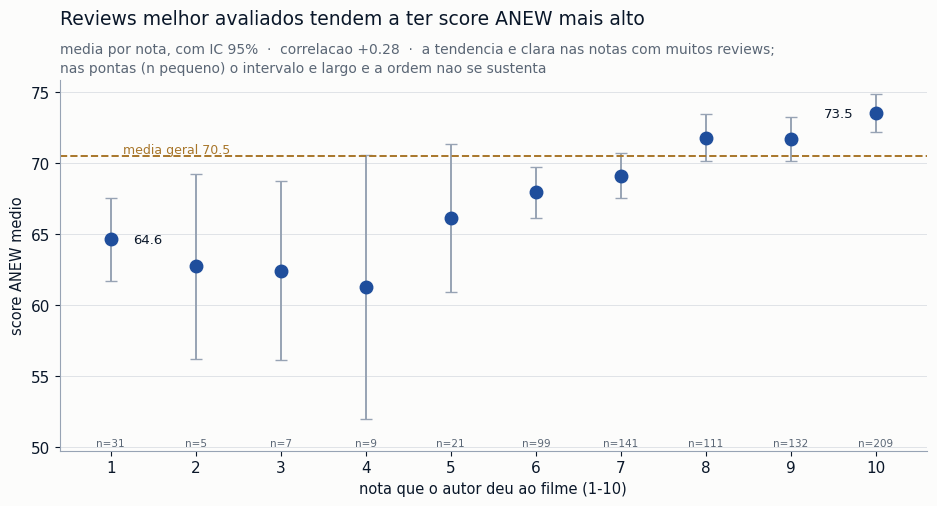

In [8]:
# ---------- Figura 2: score medio por nota do autor ----------
g = val.groupby("rating")["score"]
medias, tamanhos, erros = g.mean(), g.size(), g.std() / np.sqrt(g.size())

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.errorbar(medias.index, medias.values, yerr=1.96 * erros.values, fmt="o",
            color=AZUL, markersize=9, lw=0, elinewidth=1.4, ecolor=LINHA, capsize=4)
ax.axhline(s.mean(), color=DOURADO, lw=1.4, ls="--")

baixo = (medias - 1.96 * erros).min()
alto = (medias + 1.96 * erros).max()
ax.set_ylim(baixo - 2.2, alto + 1.0)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.4, 10.6)

ax.text(1.15, s.mean() + 0.25, f"media geral {s.mean():.1f}", fontsize=9, color=DOURADO)

for nota, lado in [(medias.index.min(), 1), (medias.index.max(), -1)]:
    ax.annotate(f"{medias[nota]:.1f}", (nota, medias[nota]), textcoords="offset points",
                xytext=(16 * lado, -3), ha="left" if lado > 0 else "right",
                fontsize=9.5, color=TINTA)

for nota, n in tamanhos.items():
    ax.annotate(f"n={n}", (nota, ax.get_ylim()[0] + 0.35), ha="center",
                fontsize=7.5, color="#5A6675")

limpar(ax, "Reviews melhor avaliados tendem a ter score ANEW mais alto",
       sub=f"media por nota, com IC 95%  ·  correlacao {rho:+.2f}  ·  a tendencia e clara nas "
           "notas com muitos reviews;\nnas pontas (n pequeno) o intervalo e largo e a ordem "
           "nao se sustenta",
       xlabel="nota que o autor deu ao filme (1-10)", ylabel="score ANEW medio")
fig.tight_layout()
fig.savefig("../figuras/fig2_score_por_nota.png", dpi=200)
plt.show()

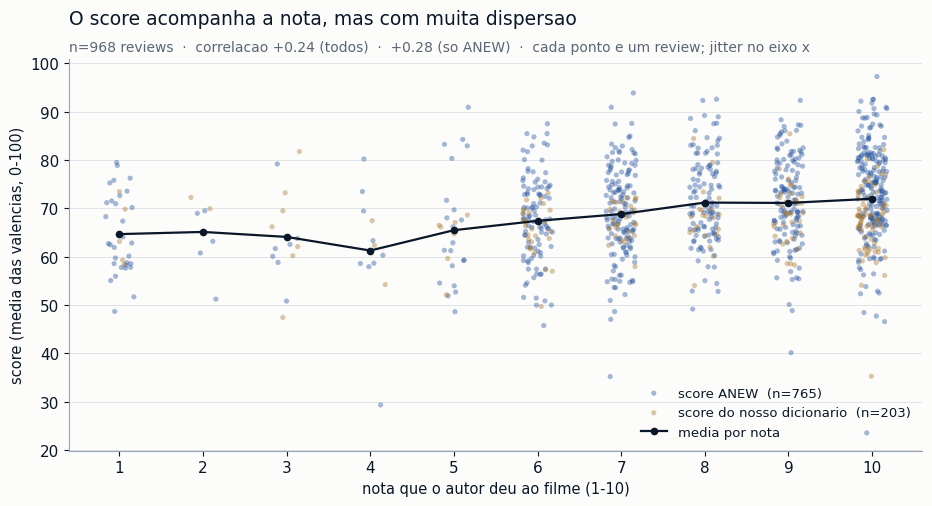

figuras salvas: fig1_distribuicao.png, fig2_score_por_nota.png, fig3_dispersao.png


In [9]:
# ---------- Figura 3: dispersao nota x score ----------
rng_fig = np.random.default_rng(7)  # jitter so para leitura: notas sao inteiras
fig, ax = plt.subplots(figsize=(9.5, 5.2))

d = val2.copy()
d["fonte"] = np.where(d["score"].notna(), "score ANEW", "score do nosso dicionario")
for fonte, cor in [("score ANEW", AZUL), ("score do nosso dicionario", DOURADO)]:
    sub = d[d["fonte"] == fonte]
    x = sub["rating"] + rng_fig.uniform(-0.18, 0.18, len(sub))
    ax.scatter(x, sub["score_final"], s=14, alpha=0.4, color=cor,
               edgecolors="none", label=f"{fonte}  (n={len(sub)})")

med = d.groupby("rating")["score_final"].mean()
ax.plot(med.index, med.values, color=TINTA, lw=1.6, marker="o", markersize=4.5,
        label="media por nota")

ax.set_xticks(range(1, 11))
ax.set_xlim(0.4, 10.6)
limpar(ax, "O score acompanha a nota, mas com muita dispersao",
       sub=f"n={len(d)} reviews  ·  correlacao {rho_todos:+.2f} (todos)  ·  "
           f"{rho_anew:+.2f} (so ANEW)  ·  cada ponto e um review; jitter no eixo x",
       xlabel="nota que o autor deu ao filme (1-10)",
       ylabel="score (media das valencias, 0-100)")
ax.legend(frameon=False, loc="lower right", fontsize=9.5)
fig.tight_layout()
fig.savefig("../figuras/fig3_dispersao.png", dpi=200)
plt.show()

print("figuras salvas:", ", ".join(sorted(os.listdir("../figuras"))))

## Limitacoes

- **Cobertura**: ~1 palavra em 16 esta no ANEW; o nosso dicionario proprio recupera parte
  do vocabulario que falta (`boring`, `worst`, `bad`), mas so o lado negativo discrimina.
- **Prosa comprime o score**: ate reviews de nota 1 pontuam ~64 — a faixa util do score
  e estreita (~62-74), o que limita a correlacao e deixa quase tudo acima do neutro 50.
- **Negacao apenas adjacente**: pega `not good`, nao pega ironia nem comparacao.
- **Vocabulario de dominio**: `villain`, `fight`, `death` descrevem a trama de um filme de
  heroi, mas entram como sentimento negativo.
- **Amostra enviesada**: reviews ordenados por utilidade, nao aleatorios — favorece textos
  longos e provavelmente infla a proporcao de positivos.